In [1]:
import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier



In [2]:
os.listdir(r"D:\all dataset2")


['DateFruit_Dataset.csv',
 'employee_turnover.csv',
 'IMDB Dataset.csv',
 'powerplant_data.csv',
 'PS_20174392719_1491204439457_log.csv',
 'shop_smart_ecommerce.csv',
 'test_batch']

In [3]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [4]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [5]:
categorical_cols 

Index(['type', 'nameOrig', 'nameDest'], dtype='object')

In [6]:
numerical_cols

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [7]:
# duplicte value
df.duplicated().sum()

np.int64(0)

In [8]:
# check f or n-f
df['isFraud'].value_counts()
df['isFraud'].mean()*100

np.float64(0.12908204481801522)

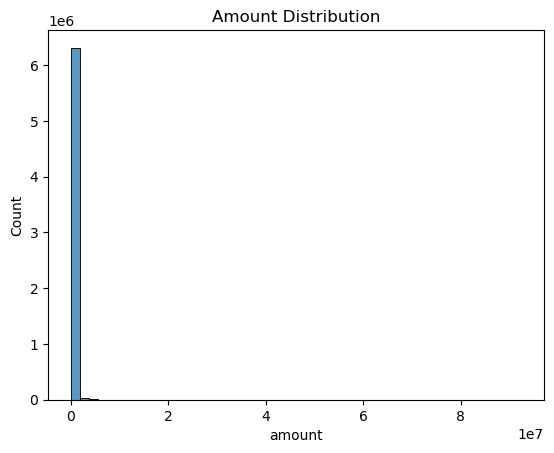

In [9]:
sns.histplot(df['amount'], bins=50)
plt.title("Amount Distribution")
plt.show()

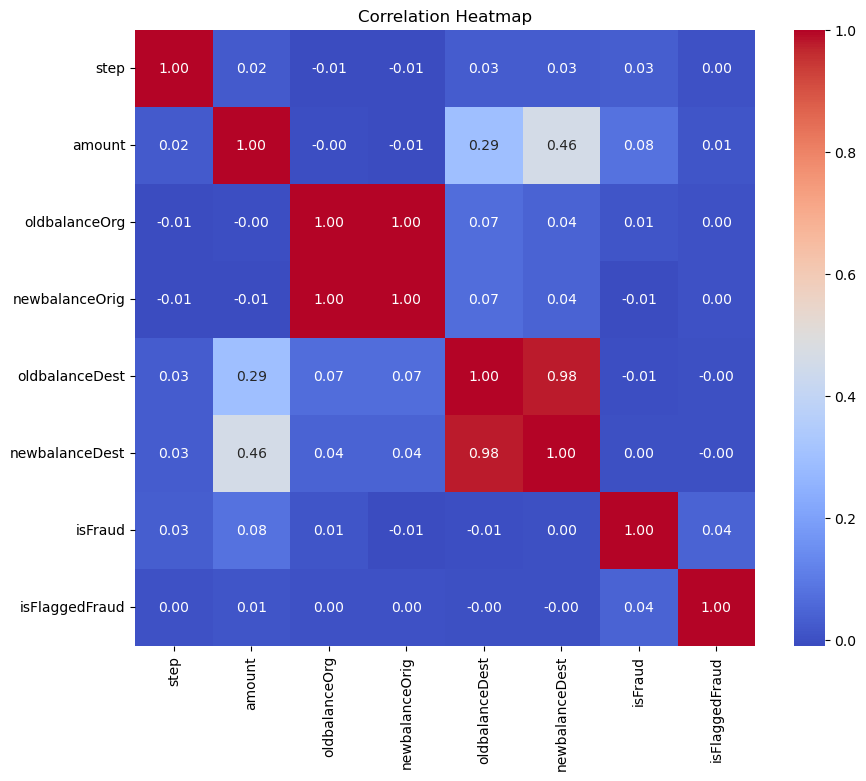

In [10]:
# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# drop useless column
df.drop(['nameOrig','nameDest'], axis=1, inplace=True)
print(df.columns.tolist())

['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [12]:
# encode
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


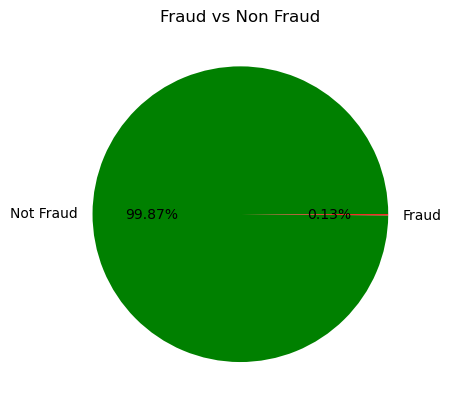

In [13]:
fraud = df['isFraud'].value_counts()
plt.pie(fraud, labels=['Not Fraud','Fraud'], autopct='%1.2f%%', colors=['green','red'])
plt.title('Fraud vs Non Fraud')
plt.show()

In [14]:
# new features 
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,9839.64
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,1864.28
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0,0.0,181.00
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0,0.0,21363.00
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,11668.14


In [15]:
from sklearn.model_selection import train_test_split

# features and target
X = df.drop(['isFraud','isFlaggedFraud'], axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5090096, 9) (1272524, 9)


In [16]:
# train model
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
# predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print('Done!')

Done!


In [18]:
# model performance
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.95      0.95      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.98      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



In [19]:
# roc auc score
from sklearn.metrics import roc_auc_score
print('ROC AUC Score:', roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.9987271114317308


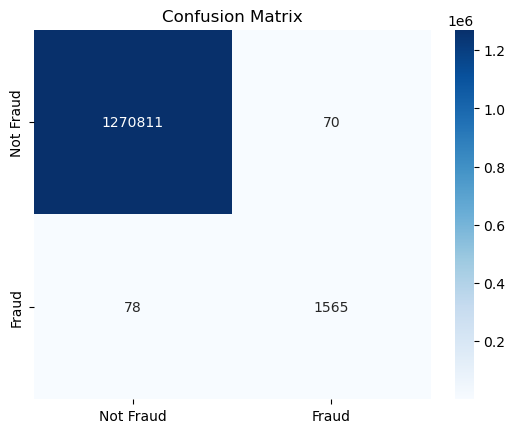

In [20]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix')
plt.show()

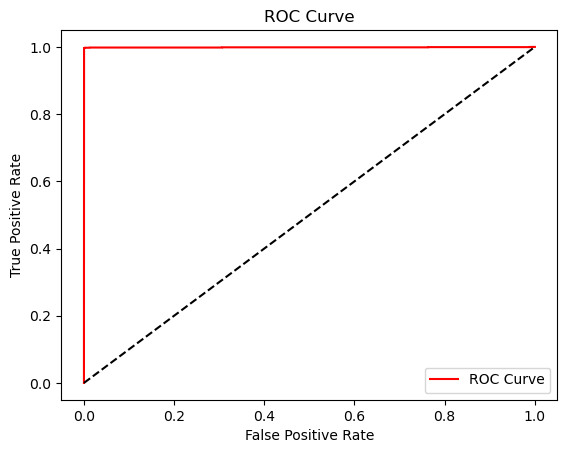

In [21]:
# roc curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='red', label='ROC Curve')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_14904\729016697.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Reds_r')


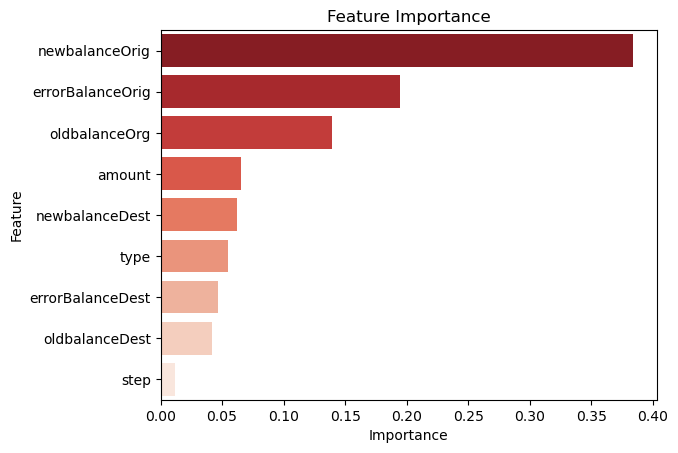

            Feature  Importance
4    newbalanceOrig    0.383844
7  errorBalanceOrig    0.194377
3     oldbalanceOrg    0.139135
2            amount    0.065155
6    newbalanceDest    0.062181
1              type    0.055102
8  errorBalanceDest    0.047009
5    oldbalanceDest    0.041804
0              step    0.011392


In [22]:
# feature importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Reds_r')
plt.title('Feature Importance')
plt.show()
print(feat_imp)

In [23]:
# Q1. Data Cleaning:
#  No missing values found
#  No duplicates found
#  Outliers exist in amount column but kept as real fraud behavior
#  nameOrig, nameDest dropped as they are just IDs

# Q2. Fraud Detection Model:
#  Used XGBoost Classifier
#  Best for large imbalanced datasets
#  80/20 train test split

# Q3. Variable Selection:
# Dropped ID columns nameOrig nameDest
#  Added errorBalanceOrig and errorBalanceDest as new features
#  These capture balance mismatch which is strong fraud signal

# Q4. Model Performance:
#  Accuracy: 1.00
#  ROC AUC Score: 0.9987
#  Fraud Precision: 0.96, Recall: 0.95

# Q5. Key Fraud Predictors:
#  errorBalanceDest
#  errorBalanceOrig
#  amount
#  type (only TRANSFER and CASH_OUT)

# Q6. Do Factors Make Sense:
#  YES! Fraudsters empty accounts via TRANSFER then CASH_OUT
#  Balance errors show money moved illegally

# Q7. Prevention Measures:
#  Flag large TRANSFER and CASH_OUT transactions
#  Two factor authentication for big transfers
#  Real time ML model monitoring

# Q8. Measuring Effectiveness:
# Track fraud rate before vs after
#  Monitor false positives monthly
#  Retrain model with new fraud data